![Back propagation.jpg](./zzzzimgs/Back%20propagation-multivariable%20chain%20rule.jpg)

This article tends to explain the backpropagation of gradient when it comes to a variable of which slight changing will affect the output of multiple output neurons.

Let's say we have a neuron network with 2 input neurons, multiple hidden layers with two neurons each, and 1 output neuron.

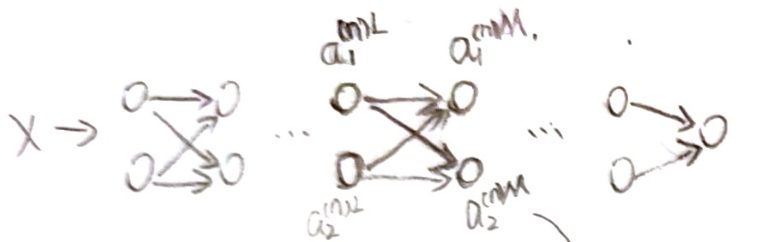

Now let's define the symbols of each neuron in the hidden layers:
We define symbol $a^{(n)L}_i$ as the output of the $i$-th neuron in the $L$-th hidden layer in the $n$-th Batch. For example, as shown in the image above, $a^{(n)L}_1$ is the output of the first neuron in the $L$-th hidden layer in the $n$-th Batch; $a^{(n)L}_2$ is the output of the second neuron in the $L$-th hidden layer in the $n$-th Batch.

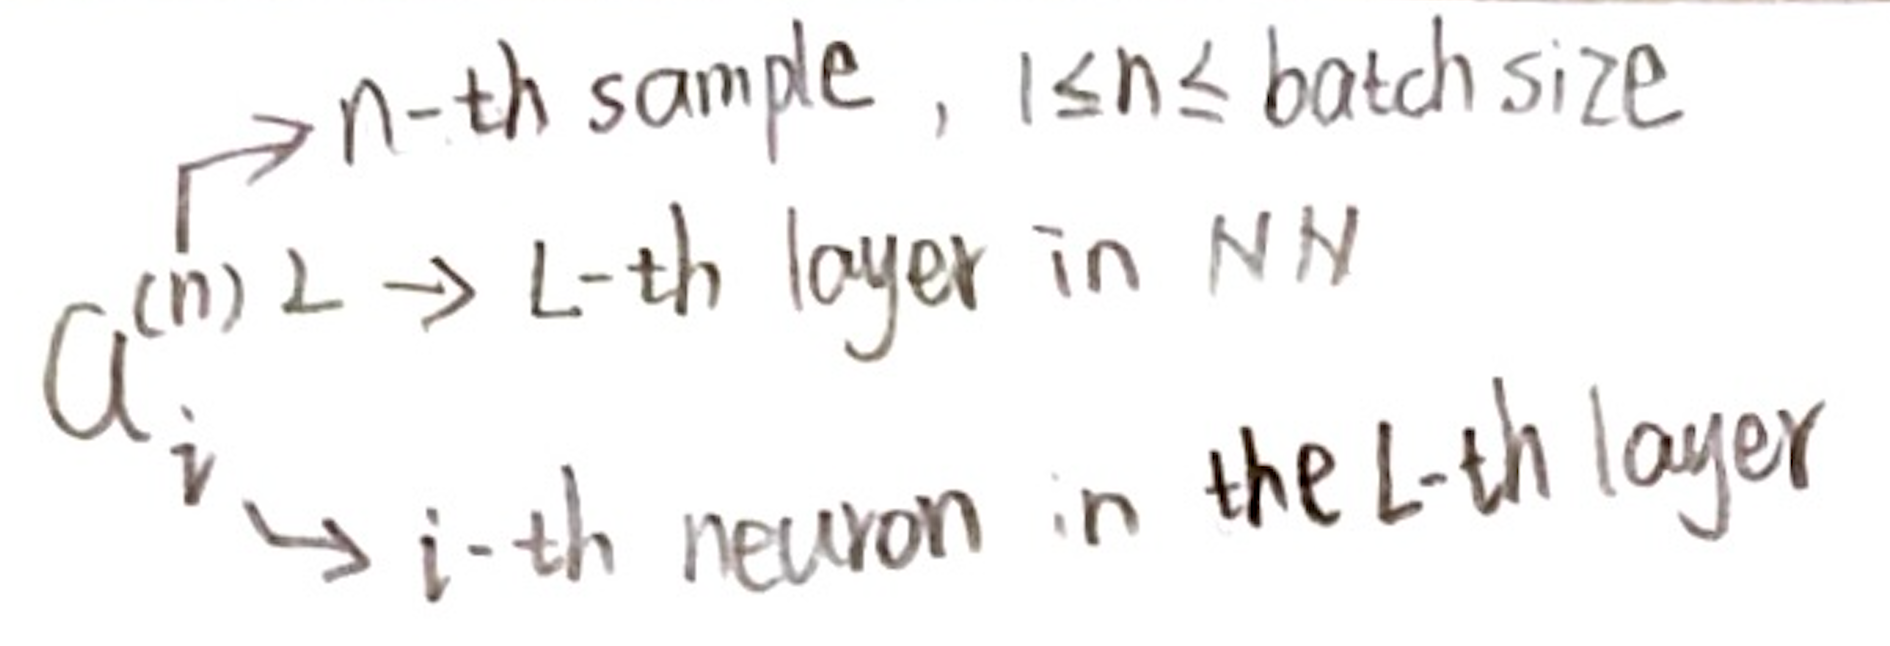

Let's say we have the value matrix of each neuron in layer $M$:
    $$
    V_M = \begin{bmatrix}
    a^{(1)M}_{1}   & a^{(1)M}_{2} \\
    a^{(2)M}_{1}   & a^{(2)M}_{2} \\
    \vdots         & \vdots \\
    a^{(BS)M}_{1}  & a^{(BS)M}_{2}
    \end{bmatrix}
    $$

In my opinion, the loss function $L$ is a function of the value matrix $V_M$:
    $$
    L(V_M): \mathbb{R}^{BS \times 2} \to \mathbb{R}
    $$
or
    $$
    L(V_M) = F(a^{(1)M}_{1}, a^{(1)M}_{2}, \cdots, a^{(BS)M}_{1}, a^{(BS)M}_{2})
    $$

According to the rules of multivariable differentiation, the differential of a multivariable function can be expressed as a linear combination of the differentials of all independent variables, each multiplied by the function's partial derivative with respect to that specific independent variable, so we have:
    $$
    dL(V_M) = \frac{\partial L}{\partial a^{(1)M}_{1}} \times \Delta a^{(1)M}_{1}
    + \frac{\partial L}{\partial a^{(1)M}_{2}} \times \Delta a^{(1)M}_{2}
    + \cdots
    + \frac{\partial L}{\partial a^{(BS)M}_{1}} \times \Delta a^{(BS)M}_{1}
    + \frac{\partial L}{\partial a^{(BS)M}_{2}} \times \Delta a^{(BS)M}_{2}
    $$

We now take a look at the relationship between the value at layer $M$ and the value at layer $L$. We assume between layer $L$ and layer $M$ there is no activation function, or the activation function is $y=x$.

so that the value relation between layer $M$ and layer $L$ is: for each neuron in layer $M$, its value is the linear combination of the values of all neurons in layer $L$ with the weights between them.
    $$
    \begin{align*}
    \Delta a^{(1)M}_{1} &= \Delta a^{(1)L}_{1} \times w_{11} + \Delta a^{(1)L}_{2} \times w_{12} \\
    \Delta a^{(1)M}_{2} &= \Delta a^{(1)L}_{1} \times w_{21} + \Delta a^{(1)L}_{2} \times w_{22} \\
    \cdots \\
    \Delta a^{(BS)M}_{1} &= \Delta a^{(BS)L}_{1} \times w_{11} + \Delta a^{(BS)L}_{2} \times w_{12} \\
    \Delta a^{(BS)M}_{2} &= \Delta a^{(BS)L}_{1} \times w_{21} + \Delta a^{(BS)L}_{2} \times w_{22} 
    \end{align*}
    $$




If we only change $\Delta a^{(1)L}_{1}$ a little bit, then ONLY the value of $\Delta a^{(1)M}_{1}$ and $\Delta a^{(1)M}_{2}$ will change a little bit as well. Other values, like $\Delta a^{(2)M}_{1}$, $\Delta a^{(2)M}_{2}$ and $\Delta a^{(BS)M}_{1}$, $\Delta a^{(BS)M}_{2}$, will not change at all.

So, the differential of $L$, when only $\Delta a^{(1)L}_{1}$ changes a little bit, is:
$$
\begin{align*}
\Delta L(V_M) &= \frac{\partial L}{\partial a^{(1)M}_{1}} \times \Delta a^{(1)M}_{1} + \frac{\partial L}{\partial a^{(1)M}_{2}} \times \Delta a^{(1)M}_{2} \\
              &= \frac{\partial L}{\partial a^{(1)M}_{1}} \times w_{11} \times \Delta a^{(1)L}_{1} + \frac{\partial L}{\partial a^{(1)M}_{2}} \times w_{12} \times \Delta a^{(1)L}_{2}
\end{align*}
$$

so the derivative of $L$ with respect to $a^{(1)L}_{1}$ is:
$$
\frac{\partial L}{\partial a^{(1)L}_{1}} = \frac{\partial L}{\partial a^{(1)M}_{1}} \times w_{11}  + \frac{\partial L}{\partial a^{(1)M}_{2}} \times w_{12}
$$